# Input-Output Space Mapping

Mapping between input and output spaces bidirectionally using GMM.

**Example:** CSTR design - map desired concentrations to reactor design parameters.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    estimate_sample_size,
    best_gmm,
    best_gmm_bic,
    cluster_stats,
    validate_gmm
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

---
<a id='mapping'></a>
## 6. Mapping Input and Output Spaces

Mapping a desired output region to the corresponding input region.

**Example:** CSTR with reactions A → B (2nd order) and A → C (1st order). Map desired concentrations (Ca, Cb) to design parameters (radius R, temperature RT).

In [ ]:
# CSTR model
H = 1     # height
vo = 1    # volumetric flow rate
Cao = 1   # inlet concentration

# Sample input space (R, RT)
bounds = [[0.1, 3], [0.1, 15]]
X = generate_samples(bounds, n_samples=512, seed=42)

R, RT = X.T
V = np.pi * R**2 * H
k1 = np.exp(-3 / RT)
k2 = np.exp(-10 / RT)

# Solve quadratic for Ca
a = V * k1
b = vo + V * k2
c = -vo * Cao
Ca = (-b + np.sqrt(b**2 - 4 * a * c)) / (2 * a)

# Compute Cb
Cb = k1 * Ca**2 * V / vo

print(f"Generated {len(X)} samples")
print(f"Ca range: [{Ca.min():.3f}, {Ca.max():.3f}]")
print(f"Cb range: [{Cb.min():.3f}, {Cb.max():.3f}]")

Generated 512 samples
Ca range: [0.061, 1.000]
Cb range: [0.000, 0.620]


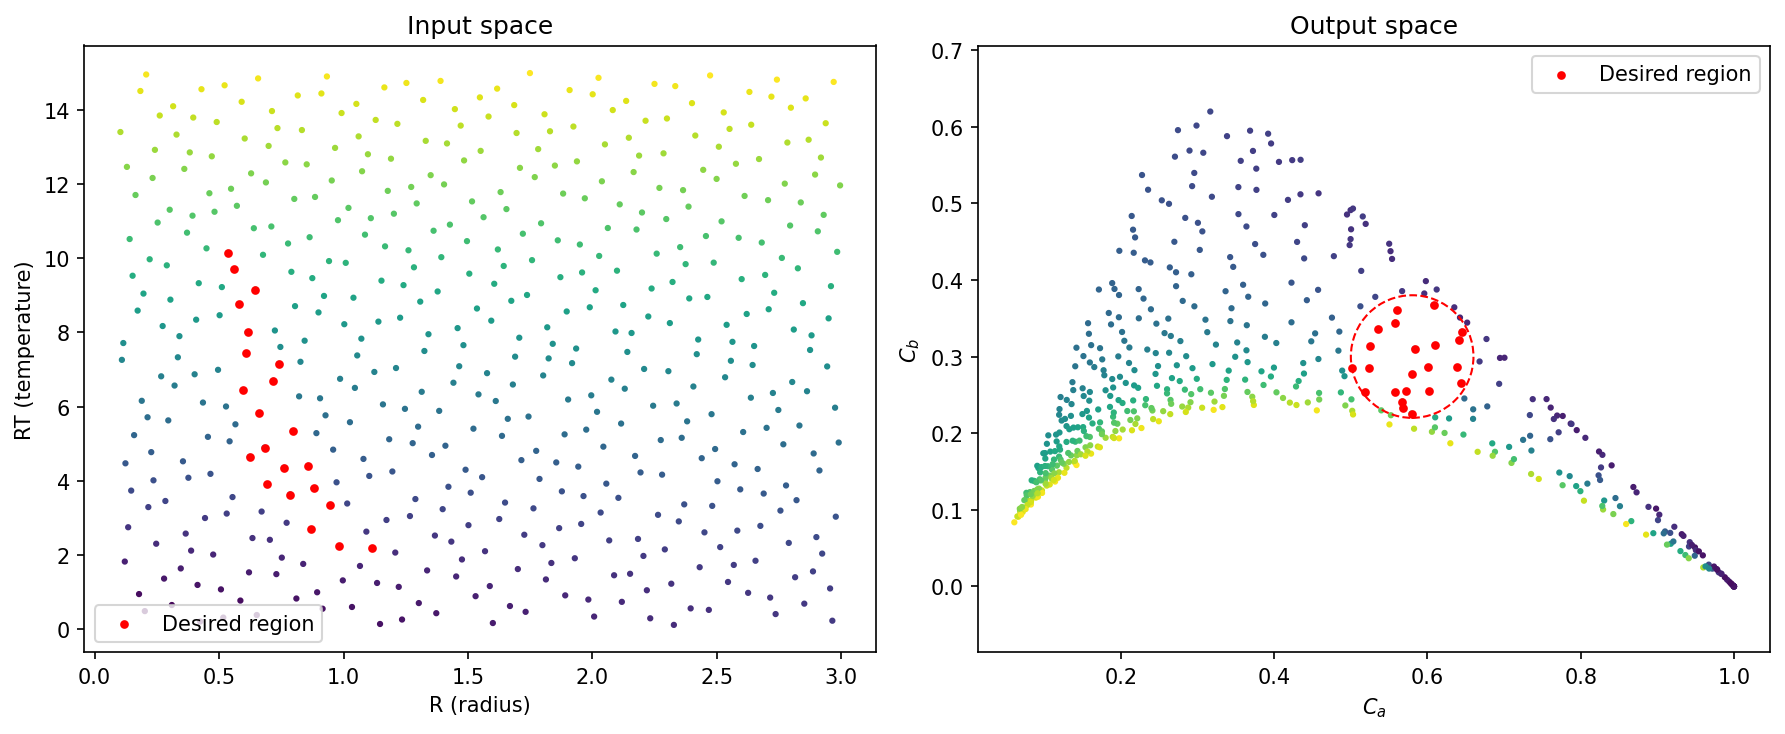

In [ ]:
# Visualize input-output relationship
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Define desired output region
center = (0.58, 0.3)
radius = 0.08
dos = ((Ca - center[0])**2 + (Cb - center[1])**2) <= radius**2

# Color by distance from origin
colors = np.sqrt(R**2 + RT**2)

axes[0].scatter(R, RT, s=4, c=colors, cmap='viridis')
axes[0].scatter(R[dos], RT[dos], c='red', s=10, label='Desired region')
axes[0].set_xlabel('R (radius)')
axes[0].set_ylabel('RT (temperature)')
axes[0].set_title('Input space')
axes[0].legend()

axes[1].scatter(Ca, Cb, s=4, c=colors, cmap='viridis')
axes[1].scatter(Ca[dos], Cb[dos], c='red', s=10, label='Desired region')
circle = plt.Circle(center, radius, fill=False, color='red', linestyle='--')
axes[1].add_patch(circle)
axes[1].set_xlabel('$C_a$')
axes[1].set_ylabel('$C_b$')
axes[1].set_title('Output space')
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Build GMM for mapping
data = np.array([R, RT, Ca, Cb]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 22 components


In [ ]:
# Generate samples in desired output region and map to input space
x1 = np.linspace(center[0] - radius, center[0] + radius, 100)
x2 = np.linspace(center[1] - radius, center[1] + radius, 100)
X1, X2 = np.meshgrid(x1, x2)
X1_flat = X1.flatten()
X2_flat = X2.flatten()

# Filter to points inside circle
ind = (X1_flat - center[0])**2 + (X2_flat - center[1])**2 <= radius**2

# Predict input space (R, RT) from output space (Ca, Cb)
pred = gmm.predict([2, 3], np.array([X1_flat[ind], X2_flat[ind]]).T)
P1, P2 = pred.T

print(f"Mapped {len(P1)} points from output to input space")

Mapped 7668 points from output to input space


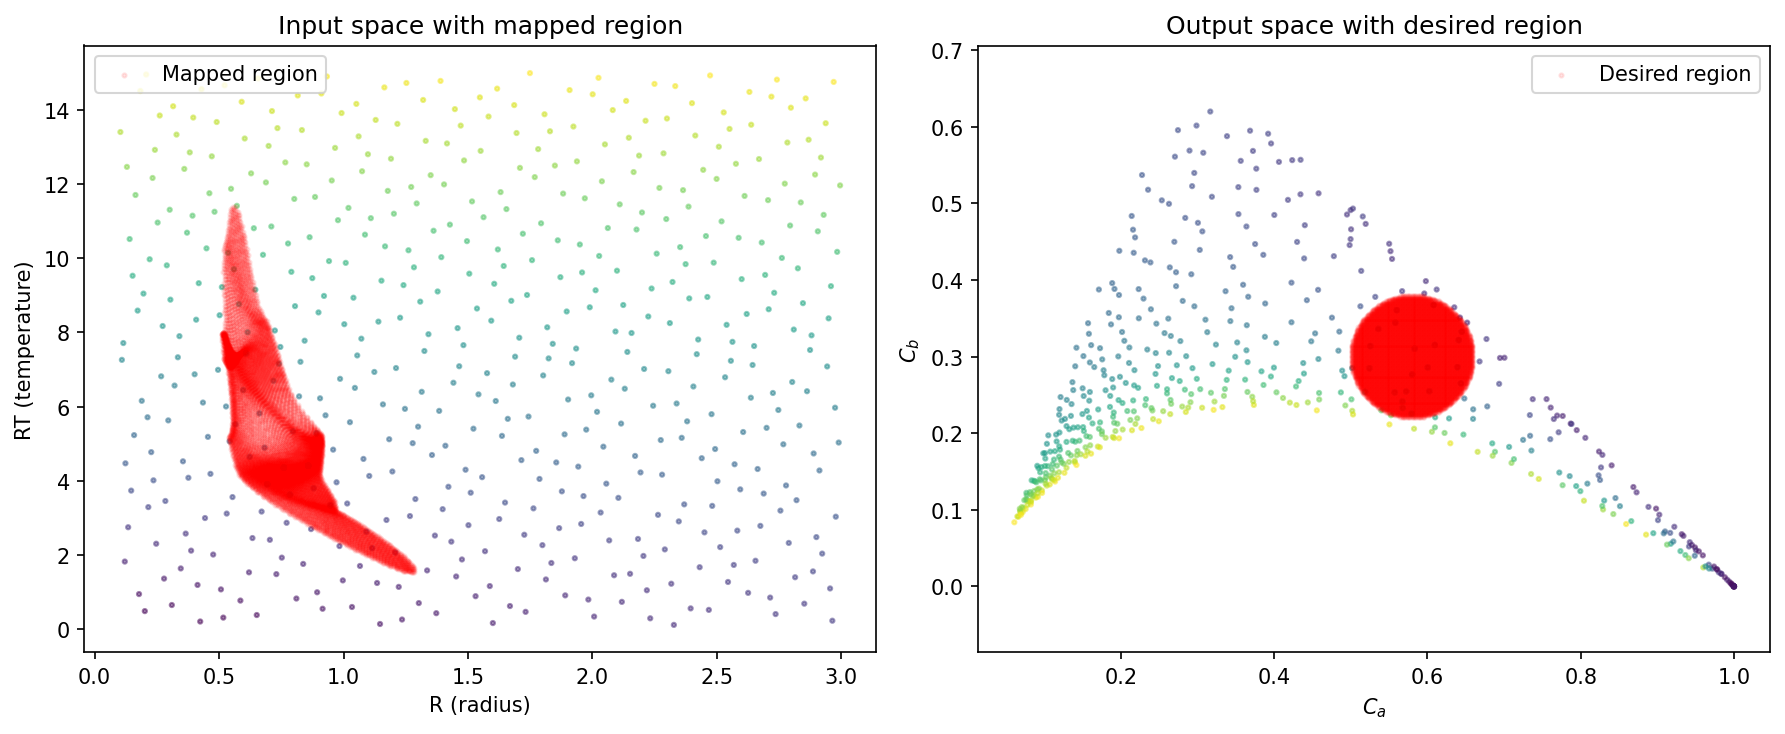

In [ ]:
# Visualize the mapping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Input space
axes[0].scatter(R, RT, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[0].scatter(P1, P2, s=4, c='red', alpha=0.1, label='Mapped region')
axes[0].set_xlabel('R (radius)')
axes[0].set_ylabel('RT (temperature)')
axes[0].set_title('Input space with mapped region')
axes[0].legend()

# Output space
axes[1].scatter(Ca, Cb, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[1].scatter(X1_flat[ind], X2_flat[ind], c='red', s=4, alpha=0.1, 
                label='Desired region')
axes[1].set_xlabel('$C_a$')
axes[1].set_ylabel('$C_b$')
axes[1].set_title('Output space with desired region')
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated generative machine learning approaches to:

1. **Root finding** - Condition on output = target value
2. **Optimization** - Include derivatives, condition on derivative = 0
3. **Constrained optimization** - Use Lagrangian (equality) or barrier method (inequality)
4. **Parameter estimation** - Condition on observations to find parameters
5. **Space mapping** - Map between input and output spaces bidirectionally

Key advantages:
- Single unified approach across problem types
- No iterative solving required at inference time
- Naturally provides uncertainty estimates via sampling
- Works bidirectionally (forward and inverse)

Limitations:
- Requires sufficient data to learn the joint distribution
- Limited to in-distribution predictions (no extrapolation)
- Solution accuracy depends on GMM fit quality